In [1]:
import seaborn as sns

In [4]:
# Load the taxis dataset
df = sns.load_dataset("taxis")
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [3]:
print("Missing values before handling:")
print(df.isnull().sum())

Missing values before handling:
pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


In [5]:
# 2. Numerical columns - impute using median
numeric_columns = df.select_dtypes(include='number').columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [6]:
# 3. Categorical columns - impute using mode
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [8]:
print(df.isnull().sum())

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


(array([17956., 17960., 17964., 17968., 17972., 17976., 17980., 17984.,
        17987.]),
 [Text(17956.0, 0, '2019-03-01'),
  Text(17960.0, 0, '2019-03-05'),
  Text(17964.0, 0, '2019-03-09'),
  Text(17968.0, 0, '2019-03-13'),
  Text(17972.0, 0, '2019-03-17'),
  Text(17976.0, 0, '2019-03-21'),
  Text(17980.0, 0, '2019-03-25'),
  Text(17984.0, 0, '2019-03-29'),
  Text(17987.0, 0, '2019-04-01')])

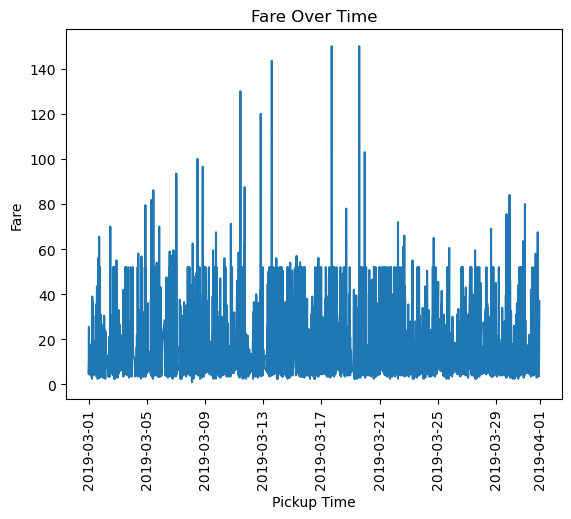

In [48]:
#creating a line chart
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Load the taxis dataset
# Convert pickup column to datetime
df['pickup'] = pd.to_datetime(df['pickup'])

# Sort the data by pickup time
df = df.sort_values('pickup')
plt.plot(df['pickup'], df['fare'])
# labelling
plt.xlabel('Pickup Time')
plt.ylabel('Fare')
plt.title('Fare Over Time')
plt.xticks(rotation=90)


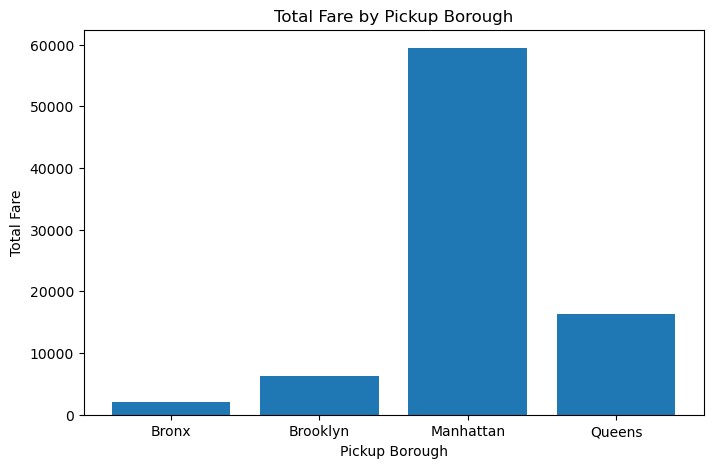

In [40]:
#creating a bar chart
# Group by pickup_borough and calculate total fare
total_fare = df.groupby('pickup_borough')['fare'].sum()

# Create bar chart
plt.figure(figsize=(8, 5))
plt.bar(total_fare.index, total_fare.values)

plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')
plt.title('Total Fare by Pickup Borough')

plt.show()

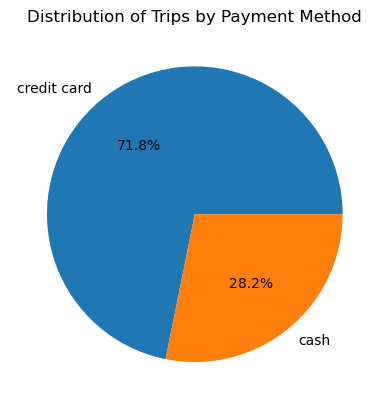

In [41]:
# Count the number of trips for each payment method
payment_counts = df['payment'].value_counts()

# Creating a pie chart


plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%'
)

plt.title('Distribution of Trips by Payment Method')

plt.show()

Text(0.5, 1.0, 'Distribution of Taxi Trip Distance')

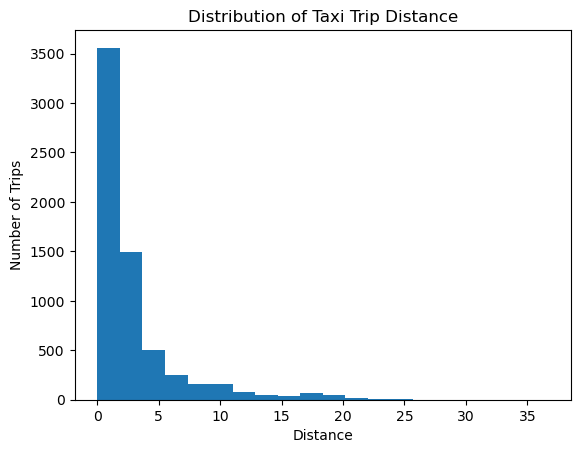

In [42]:
# Creating a  histogram
plt.hist(df['distance'], bins=20)
plt.xlabel('Distance')
plt.ylabel('Number of Trips')
plt.title('Distribution of Taxi Trip Distance')


Text(0.5, 1.0, 'Distribution of Tip Amounts by Pickup Borough')

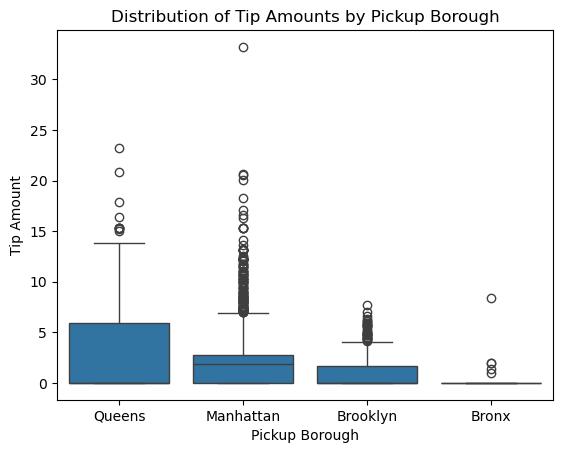

In [43]:
#creating a box plotS
sns.boxplot(x='pickup_borough', y='tip', data=df)
plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount')
plt.title('Distribution of Tip Amounts by Pickup Borough')

Text(0.5, 1.0, 'Number of Trips by Pickup Borough')

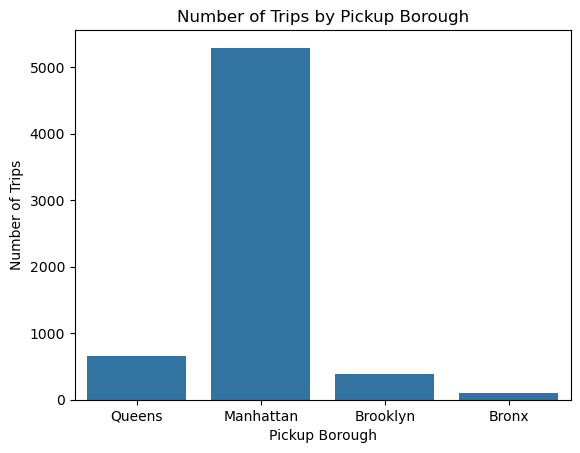

In [44]:
#creating a count plot
sns.countplot(x='pickup_borough', data=df)
plt.xlabel('Pickup Borough')
plt.ylabel('Number of Trips')
plt.title('Number of Trips by Pickup Borough')


Text(0.5, 1.0, 'Relationship Between Distance and Fare')

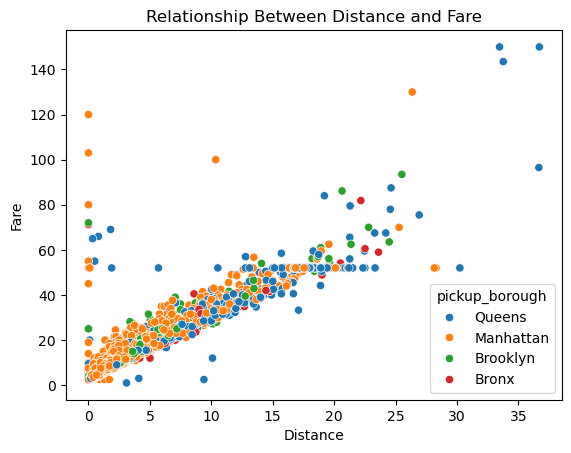

In [38]:
# creating a scatter plot
sns.scatterplot(
    x='distance',
    y='fare',
    hue='pickup_borough',
    data=df
)

plt.xlabel('Distance')
plt.ylabel('Fare')
plt.title('Relationship Between Distance and Fare')


Text(0.5, 1.0, 'Correlation Heatmap of Taxi Variables')

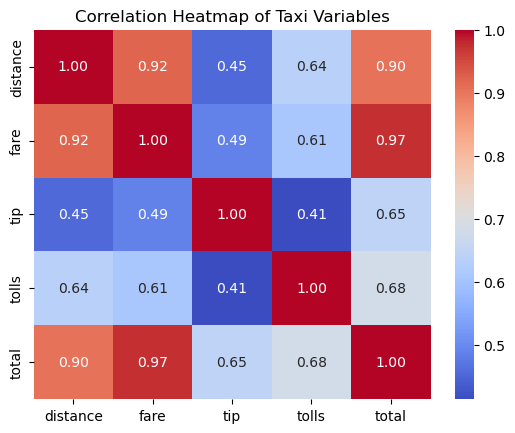

In [45]:
# Select the required numerical columns
df_corr = df[['distance', 'fare', 'tip', 'tolls', 'total']]
# Create correlation matrix
corr_matrix = df_corr.corr()
# Creating a heatmap
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Taxi Variables')


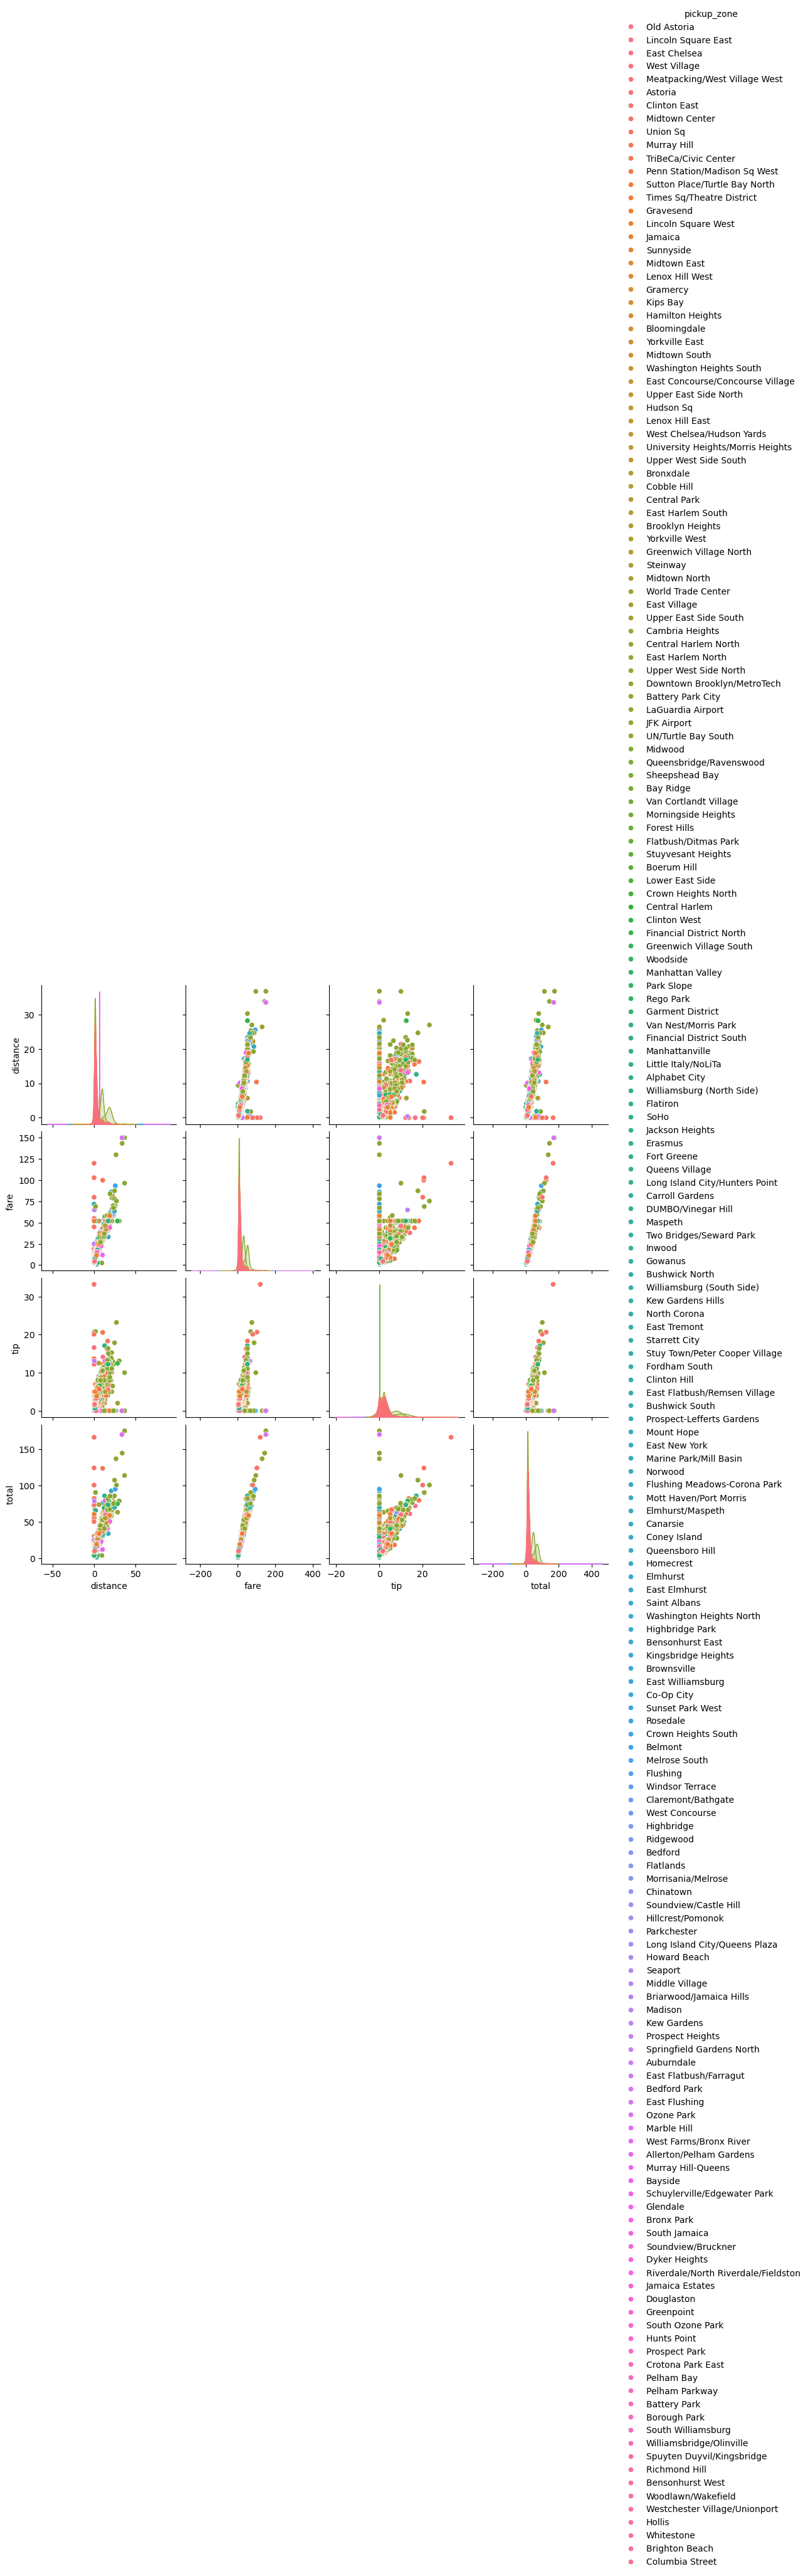

In [46]:
# Creating a pair plot
sns.pairplot(
    df,
    vars=['distance', 'fare', 'tip', 'total'],
    hue='pickup_zone'
)
plt.show()


Text(0.5, 1.0, 'Distribution of Fare by Payment Method')

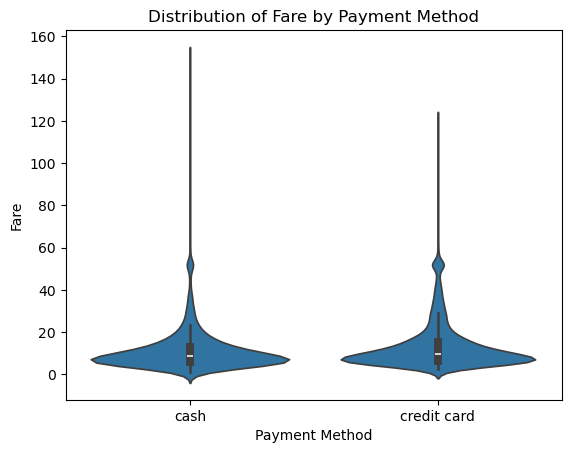

In [47]:

# Creating a violin plot
sns.violinplot(x='payment', y='fare', data=df)
plt.xlabel('Payment Method')
plt.ylabel('Fare')
plt.title('Distribution of Fare by Payment Method')
